# CSCI E-89 -- Deep Learning, HW03, Problem 1
### Building an Image Classifier with PyTorch (FashionMNIST)

**Paul Schwartzberg**

**GitHub repository:** [schwartzberg/dec03c](https://github.com/schwartzberg/dec03c), branch [`claude/exciting-einstein-p34a0s`](https://github.com/schwartzberg/dec03c/tree/claude/exciting-einstein-p34a0s) -- every cell below was generated incrementally in a Claude Code session, one request at a time, and pushed to that repository as its own script as soon as it was written and tested. This notebook reassembles those scripts, in execution order, into one coherent pipeline. Each section below names and links its source file in the repository.

The reference template is the "Building an Image Classifier with PyTorch" section of `10_neural_nets_with_pytorch.ipynb` (Chapter 10, Geron, *Hands-On Machine Learning*, PyTorch edition). That section trains the model but discards the per-epoch history (`_ = train2(...)`), so it never plots training accuracy -- Part 7 below is the piece added for this assignment.

## 1. Load the Data
**Source:** [`01_load_data.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/01_load_data.py)

Download FashionMNIST and split it into training, validation and test sets.

In [1]:
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

print(f"Training images:   {len(train_data):,}")
print(f"Validation images: {len(valid_data):,}")
print(f"Test images:       {len(test_data):,}")

Training images:   55,000
Validation images: 5,000
Test images:       10,000


## 2. Wrap the Data in DataLoaders
**Source:** [`02_data_loaders.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/02_data_loaders.py)

Batch size 32, with the training set shuffled.

In [2]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   1719
Validation batches: 157
Test batches:       313


## 3. Inspect One Sample
**Source:** [`03_inspect_sample.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/03_inspect_sample.py)

Look at one training image's tensor shape, data type and class name.

In [3]:
X_sample, y_sample = train_data[0]

print(f"Image shape: {X_sample.shape}")   # [channels, rows, columns]
print(f"Image dtype: {X_sample.dtype}")
print(f"Class name:  {train_and_valid_data.classes[y_sample]}")

Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Class name:  Ankle boot


## 4. Define the Model
**Source:** [`04_model.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/04_model.py)

A two-hidden-layer MLP (300, then 100 neurons), plus its loss function, optimizer and accuracy metric.

In [4]:
import torch.nn as nn
import torchmetrics

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"


class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                         n_classes=10).to(device)

xentropy = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

print(f"Device: {device}")
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cpu
ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610


## 5. Define the Training Function
**Source:** [`05_training_function.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/05_training_function.py)

Runs one epoch at a time and records training loss, training accuracy and validation accuracy after each epoch.

In [5]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train accuracy: {history['train_metrics'][-1]:.4f}, "
              f"valid accuracy: {history['valid_metrics'][-1]:.4f}")
    return history

## 6. Train for 20 Epochs
**Source:** [`06_train.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/06_train.py)

The book's own version of this section discards the returned history (`_ = train2(...)`); here it's kept.

In [6]:
n_epochs = 20
history = train2(model, optimizer, xentropy, accuracy, train_loader,
                  valid_loader, n_epochs)

print(f"Final train accuracy: {history['train_metrics'][-1]:.4f}")
print(f"Final valid accuracy: {history['valid_metrics'][-1]:.4f}")

Epoch 1/20, train loss: 0.6060, train accuracy: 0.7814, valid accuracy: 0.8424


Epoch 2/20, train loss: 0.4061, train accuracy: 0.8496, valid accuracy: 0.8402


Epoch 3/20, train loss: 0.3630, train accuracy: 0.8661, valid accuracy: 0.8494


Epoch 4/20, train loss: 0.3355, train accuracy: 0.8768, valid accuracy: 0.8638


Epoch 5/20, train loss: 0.3154, train accuracy: 0.8829, valid accuracy: 0.8782


...

Epoch 16/20, train loss: 0.2078, train accuracy: 0.9196, valid accuracy: 0.8886


Epoch 17/20, train loss: 0.2033, train accuracy: 0.9233, valid accuracy: 0.8870


Epoch 18/20, train loss: 0.1991, train accuracy: 0.9230, valid accuracy: 0.8846


Epoch 19/20, train loss: 0.1916, train accuracy: 0.9266, valid accuracy: 0.8812


Epoch 20/20, train loss: 0.1876, train accuracy: 0.9286, valid accuracy: 0.8788
Final train accuracy: 0.9286
Final valid accuracy: 0.8788


## 7. Plot Training Accuracy
**Source:** [`07_plot_accuracy.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/07_plot_accuracy.py)

The one addition this assignment asks for beyond the book's template. Validation accuracy is plotted alongside it, since train2 already computes it at no extra cost.

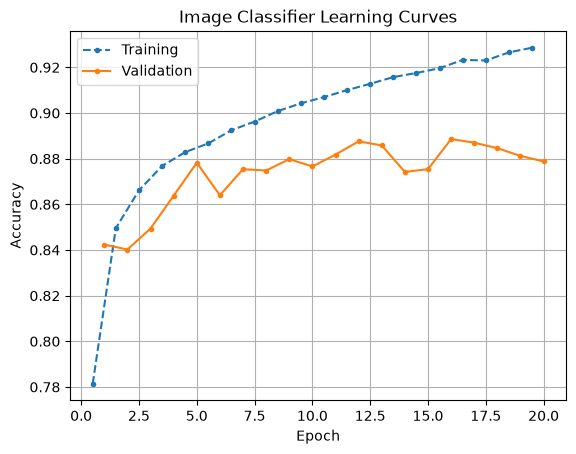

In [7]:
import numpy as np
import matplotlib.pyplot as plt

n_epochs = len(history["train_metrics"])

plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metrics"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.title("Image Classifier Learning Curves")
plt.legend()
plt.show()

## 8. Evaluate Predictions
**Source:** [`08_evaluate_predictions.py`](https://github.com/schwartzberg/dec03c/blob/claude/exciting-einstein-p34a0s/08_evaluate_predictions.py)

Predict 3 validation images and show class names, probabilities, top-4 guesses, and the total parameter count.

In [8]:
model.eval()

import torch.nn.functional as F

X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)

predicted_classes = [train_and_valid_data.classes[i] for i in y_pred]
true_classes = [train_and_valid_data.classes[i] for i in y_new[:3]]

print("Predicted:", predicted_classes)
print("True:     ", true_classes)
print("All correct!" if predicted_classes == true_classes
      else "Not all correct.")

y_proba = F.softmax(y_pred_logits, dim=1)
print("Probabilities (rounded):")
print(y_proba.round(decimals=3))

y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1)
print("Top-4 class indices per image:")
print(y_top4_indices)
print("Top-4 probabilities per image:")
print(y_top4_probas.round(decimals=3))

n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")

Predicted: ['Sneaker', 'Coat', 'Pullover']
True:      ['Sneaker', 'Coat', 'Pullover']
All correct!
Probabilities (rounded):
tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8590, 0.0000,
         0.1410],
        [0.0000, 0.0000, 0.0070, 0.0000, 0.9930, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.5920, 0.0000, 0.2120, 0.0000, 0.1910, 0.0000, 0.0010,
         0.0000]])
Top-4 class indices per image:
tensor([[7, 9, 5, 1],
        [4, 2, 6, 8],
        [2, 4, 6, 0]])
Top-4 probabilities per image:
tensor([[0.8590, 0.1410, 0.0000, 0.0000],
        [0.9930, 0.0070, 0.0000, 0.0000],
        [0.5930, 0.2120, 0.1920, 0.0040]])
Total trainable parameters: 266,610


---

# Dialogue Summary

**Paul Schwartzberg — CSCI E-89, HW03**

**Goal:** using Claude Code connected to [schwartzberg/dec03c](https://github.com/schwartzberg/dec03c), incrementally rebuild the "Building an Image Classifier with PyTorch" section of `10_neural_nets_with_pytorch.ipynb` (FashionMNIST, Chapter 10, Geron), and add the one thing that section doesn't do on its own: a plot of training accuracy across epochs.

**Process:** before writing anything, we read the reference notebook's actual cells (111-132) rather than assuming their content, to pin down the exact architecture, hyperparameters, and -- critically -- the exact gap to fill. The book's own version trains the model but discards its per-epoch history (`_ = train2(...)`), so it never plots anything. That became the one deliberate addition on top of the template.

From there, the model was built as eight separate requests, one script per request, each tested by actually running it before being committed and pushed to GitHub -- nothing went into the repository unverified:

1. `01_load_data.py` -- download FashionMNIST, split 55,000 / 5,000 / 10,000 into train / validation / test.
2. `02_data_loaders.py` -- wrap each set in a DataLoader, batch size 32.
3. `03_inspect_sample.py` -- confirm one image's shape, data type and class name.
4. `04_model.py` -- define the classifier (784 to 300 to 100 to 10, ReLU activations), its loss (cross-entropy), optimizer (SGD, lr=0.1) and accuracy metric.
5. `05_training_function.py` -- a training function that records training and validation accuracy every epoch, not just loss.
6. `06_train.py` -- the real 20-epoch run. Final training accuracy 92.9%, validation accuracy 87.9%.
7. `07_plot_accuracy.py` -- the addition this assignment asks for: training and validation accuracy plotted against epoch.
8. `08_evaluate_predictions.py` -- sample predictions on 3 validation images, softmax probabilities, top-4 guesses, and the parameter count (266,610).

**Result:** all eight scripts, tested individually, were reassembled into one notebook, `e89_Schwartzberg_Paul_HW03_Prob1.ipynb`, in execution order, each section labeled with and linked to its source script in the repository. The assembled notebook was then executed top to bottom as one run, to confirm it holds together as a single coherent pipeline and not just as separate working pieces -- it produced the same results either way, since every step is seeded.

**Repository:** https://github.com/schwartzberg/dec03c, branch `claude/exciting-einstein-p34a0s`.
